In [ ]:
!pip install pandas
!pip install scikit-learn
!pip install tensorflow
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Attention, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from pathlib import Path

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import shutil

# Specifying the path 
drive_folder_path = '/content/drive/My Drive/daily_dataset'

print("Contents of the folder:")
for item in os.listdir(drive_folder_path):
    print(item)


Contents of the folder:
block_102.csv
block_101.csv
block_10.csv
block_1.csv
block_100.csv
block_0.csv
block_108.csv
block_107.csv
block_104.csv
block_106.csv
block_109.csv
block_103.csv
block_105.csv
block_14.csv
block_17.csv
block_11.csv
block_110.csv
block_12.csv
block_13.csv
block_16.csv
block_111.csv
block_15.csv
block_21.csv
block_19.csv
block_23.csv
block_22.csv
block_18.csv
block_2.csv
block_20.csv
block_27.csv
block_29.csv
block_28.csv
block_24.csv
block_3.csv
block_26.csv
block_25.csv
block_35.csv
block_36.csv
block_37.csv
block_34.csv
block_33.csv
block_32.csv
block_31.csv
block_30.csv
block_4.csv
block_38.csv
block_42.csv
block_41.csv
block_39.csv
block_40.csv
block_44.csv
block_43.csv
block_47.csv
block_46.csv
block_50.csv
block_49.csv
block_45.csv
block_5.csv
block_48.csv
block_52.csv
block_56.csv
block_53.csv
block_55.csv
block_51.csv
block_57.csv
block_54.csv
block_63.csv
block_6.csv
block_62.csv
block_58.csv
block_64.csv
block_61.csv
block_59.csv
block_60.csv
block_71.

In [4]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


path = '/content/drive/My Drive/daily_dataset/'
block_path = Path(path)

skip_files = ['informations_households.csv', 'uk_bank_holidays.csv', 'weather_hourly_darksky.csv']

# Placeholder for all DataFrames
block_df_l = []

# Processing each CSV file
for file in tqdm(sorted(list(block_path.glob("*.csv"))), desc="Processing Blocks.."):
    filename = file.name

    if filename in skip_files:
        print(f"Skipping file {filename} as it does not contain a 'day' column.")
        continue

    try:
      
        block_df = pd.read_csv(file, parse_dates=False)
        if 'day' not in block_df.columns:
            print(f"'day' column missing in file {file}")
            continue

        try:
            block_df['day'] = pd.to_datetime(block_df['day'], format='%Y-%m-%d', errors='coerce')
            block_df.dropna(subset=['day'], inplace=True)
        except ValueError as e:
            print(f"Error parsing dates in file {file}: {e}")
            continue  

        block_df = block_df.loc[block_df['day'] >= "2012-01-01"]
        block_df_l.append(block_df)

    except Exception as e:
        print(f"Error reading file {file}: {e}")
        continue

# Combining the data into a single DataFrame 
if block_df_l:
    combined_df = pd.concat(block_df_l, ignore_index=True)

    # Calculating weekly and monthly averages 
    combined_df['weekly_energy_mean'] = combined_df.groupby('LCLid')['energy_mean'].transform(lambda x: x.rolling(window=7).mean())
    combined_df['monthly_energy_mean'] = combined_df.groupby('LCLid')['energy_mean'].transform(lambda x: x.rolling(window=30).mean())
    combined_df.dropna(subset=['weekly_energy_mean', 'monthly_energy_mean'], inplace=True)

    output_path = '/content/drive/My Drive//daily_energy_with_averages.csv'
    combined_df.to_csv(output_path, index=False)

    daily_energy_consumption = pd.read_csv(output_path, parse_dates=['day'])

    print(daily_energy_consumption.columns)
else:
    print("No valid data files were processed.")


Processing Blocks..: 100%|██████████| 112/112 [00:07<00:00, 15.68it/s]


Index(['LCLid', 'day', 'energy_median', 'energy_mean', 'energy_max',
       'energy_count', 'energy_std', 'energy_sum', 'energy_min',
       'weekly_energy_mean', 'monthly_energy_mean'],
      dtype='object')


In [5]:
# Find Maximum Date
max_date = daily_energy_consumption['day'].max()
print("Maximum date found across all CSVs:", max_date)
print(daily_energy_consumption.head())

Maximum date found across all CSVs: 2014-02-28 00:00:00
       LCLid        day  energy_median  energy_mean  energy_max  energy_count  \
0  MAC000002 2012-11-10         0.2160     0.275938       1.062            48   
1  MAC000002 2012-11-11         0.1850     0.222896       1.149            48   
2  MAC000002 2012-11-12         0.2050     0.256688       1.124            48   
3  MAC000002 2012-11-13         0.1730     0.213833       0.907            48   
4  MAC000002 2012-11-14         0.1745     0.225417       1.154            48   

   energy_std  energy_sum  energy_min  weekly_energy_mean  monthly_energy_mean  
0    0.227563      13.245       0.074            0.278729             0.286755  
1    0.176689      10.699       0.074            0.267395             0.289041  
2    0.223121      12.321       0.074            0.259139             0.289898  
3    0.154893      10.264       0.075            0.254976             0.287843  
4    0.181445      10.820       0.076            0.2

In [6]:
import pandas as pd

daily_energy_consumption = pd.read_csv('/content/drive/My Drive//daily_energy_with_averages.csv', parse_dates=['day'])

# Merging household information
household_info = pd.read_csv('/informations_households.csv')
daily_energy_consumption = daily_energy_consumption.merge(household_info, on='LCLid', how='left')

# Merging holiday data
holiday_data = pd.read_csv('/uk_bank_holidays.csv', parse_dates=['Bank holidays'])
holiday_data['is_holiday'] = 1  
holiday_data = holiday_data.rename(columns={'Bank holidays': 'day'}) 
holiday_data.set_index('day', inplace=True)
daily_energy_consumption = daily_energy_consumption.merge(holiday_data[['is_holiday', 'Type']],
                                                          on='day',
                                                          how='left')
daily_energy_consumption['is_holiday'].fillna(0, inplace=True) 
daily_energy_consumption['Type'].fillna('None', inplace=True)   
print(daily_energy_consumption[['day', 'is_holiday', 'Type']].head())

# merging weather data
weather_data = pd.read_csv('/weather_daily_darksky.csv', parse_dates=['time'])
weather_data = weather_data.rename(columns={'time': 'day'}) 
daily_energy_consumption = daily_energy_consumption.merge(weather_data, on='day', how='left')
print(daily_energy_consumption[['day'] + list(weather_data.columns)].head())

daily_energy_consumption['day_of_week'] = daily_energy_consumption['day'].dt.dayofweek
daily_energy_consumption['month'] = daily_energy_consumption['day'].dt.month

daily_energy_consumption['previous_week_energy_mean'] = daily_energy_consumption.groupby('LCLid')['energy_mean'].shift(7).rolling(7).mean()
daily_energy_consumption.dropna(subset=['previous_week_energy_mean'], inplace=True)

# Add lagged features for daily forecasting
daily_energy_consumption['last_3_days_energy_mean'] = daily_energy_consumption.groupby('LCLid')['energy_mean'].transform(lambda x: x.rolling(window=3).mean())

# Add lagged features for weekly forecasting 
daily_energy_consumption['last_3_weeks_energy_mean'] = daily_energy_consumption.groupby('LCLid')['energy_mean'].transform(lambda x: x.rolling(window=21).mean())

# Add lagged features for monthly forecasting 
daily_energy_consumption['last_3_months_energy_mean'] = daily_energy_consumption.groupby('LCLid')['energy_mean'].transform(lambda x: x.rolling(window=90).mean())

daily_energy_consumption.dropna(inplace=True)

print(daily_energy_consumption[['last_3_days_energy_mean','last_3_weeks_energy_mean', 'last_3_months_energy_mean']].head())

daily_energy_consumption.dropna(subset=['previous_week_energy_mean'], inplace=True)

# One-Hot Encoding 
categorical_features = ['stdorToU', 'Acorn', 'Acorn_grouped', 'file', 'Type', 'precipType', 'icon', 'summary']
daily_energy_consumption = pd.get_dummies(daily_energy_consumption, columns=categorical_features, drop_first=True)

print(daily_energy_consumption.columns)


         day  is_holiday  Type
0 2012-11-10         0.0  None
1 2012-11-11         0.0  None
2 2012-11-12         0.0  None
3 2012-11-13         0.0  None
4 2012-11-14         0.0  None
         day  temperatureMax   temperatureMaxTime  windBearing  \
0 2012-11-10           10.31  2012-11-10 04:00:00        220.0   
1 2012-11-11            9.87  2012-11-11 14:00:00        247.0   
2 2012-11-12           12.18  2012-11-12 20:00:00        204.0   
3 2012-11-13           14.66  2012-11-13 13:00:00        203.0   
4 2012-11-14           12.62  2012-11-14 14:00:00        113.0   

                  icon  dewPoint   temperatureMinTime  cloudCover  windSpeed  \
0    partly-cloudy-day      7.38  2012-11-10 23:00:00        0.49       2.38   
1  partly-cloudy-night      3.49  2012-11-11 07:00:00        0.22       1.98   
2    partly-cloudy-day      7.51  2012-11-12 03:00:00        0.50       3.06   
3  partly-cloudy-night     10.34  2012-11-13 07:00:00        0.54       3.23   
4                

In [7]:
from sklearn.preprocessing import MinMaxScaler

# Excluding columns that are targets
exclude_columns = [
    'LCLid', 'day',
    'energy_sum', 'energy_mean', 'weekly_energy_mean', 'monthly_energy_mean'
]
features = [col for col in daily_energy_consumption.columns if col not in exclude_columns]
X = daily_energy_consumption[features]

y_daily = daily_energy_consumption['energy_mean']
y_weekly = daily_energy_consumption['weekly_energy_mean']
y_monthly = daily_energy_consumption['monthly_energy_mean']

non_numeric_columns = X.select_dtypes(include=['object', 'datetime64']).columns
X_numeric = X.drop(columns=non_numeric_columns)
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X_numeric)
scaler_y = MinMaxScaler()

y_daily_scaled = scaler_y.fit_transform(y_daily.values.reshape(-1, 1)).ravel()
y_weekly_scaled = scaler_y.fit_transform(y_weekly.values.reshape(-1, 1)).ravel()
y_monthly_scaled = scaler_y.fit_transform(y_monthly.values.reshape(-1, 1)).ravel()

# Verify the shapes of the scaled data
print(f'Features shape: {X_scaled.shape}')
print(f'Daily target shape: {y_daily_scaled.shape}')
print(f'Weekly target shape: {y_weekly_scaled.shape}')
print(f'Monthly target shape: {y_monthly_scaled.shape}')

Features shape: (1369536, 230)
Daily target shape: (1369536,)
Weekly target shape: (1369536,)
Monthly target shape: (1369536,)


In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns
from sklearn.pipeline import Pipeline

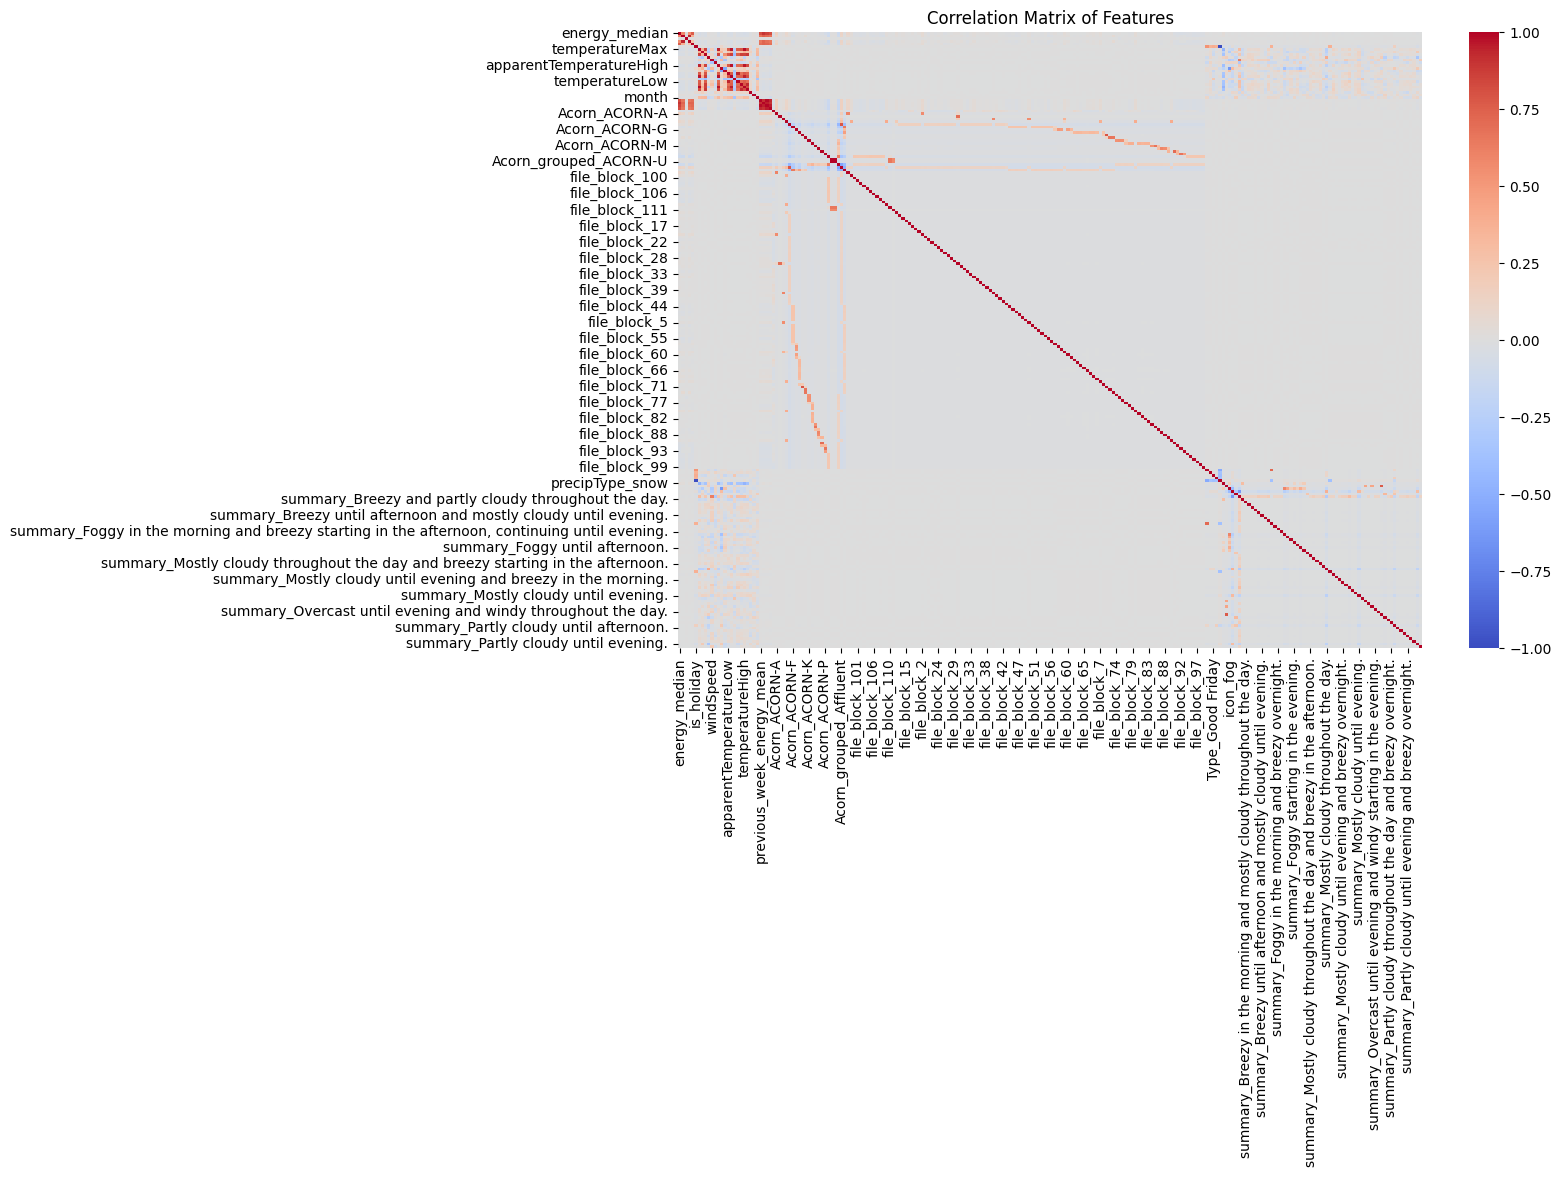

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)
correlation_matrix = X_scaled_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

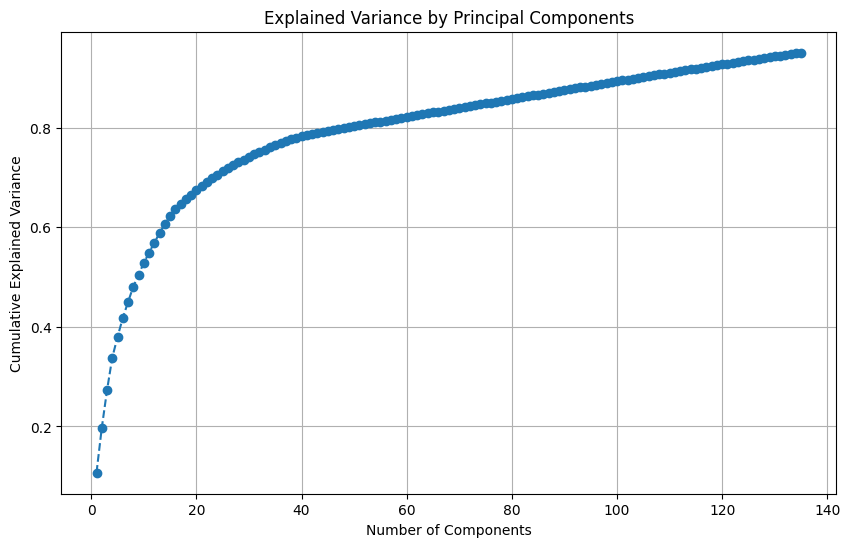

In [ ]:
from sklearn.decomposition import PCA

imputer = SimpleImputer(strategy='mean') 
X_scaled_imputed = imputer.fit_transform(X_scaled)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled_imputed)
explained_variance = pca.explained_variance_ratio_.cumsum()

# Visualizing the Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [ ]:
threshold = 0.95
n_components = next(i for i, cumulative_variance in enumerate(explained_variance) if cumulative_variance >= threshold) + 1
print(f"Number of components to retain {threshold*100}% of variance: {n_components}")

Number of components to retain 95.0% of variance: 135


In [ ]:
imputer = SimpleImputer(strategy='mean')  
X_scaled_imputed = imputer.fit_transform(X_scaled)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV

X_scaled_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)
X_sample = X_scaled_df.sample(n=10000, random_state=42)
y_sample = y_daily_scaled[X_sample.index] 

lasso_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000))  
])

lasso_pipeline.fit(X_sample, y_sample)  
coef = pd.Series(lasso_pipeline.named_steps['lasso'].coef_, index=X_numeric.columns)
selected_features_lasso = coef[coef != 0].index.tolist()

print("Features selected by Lasso:", selected_features_lasso)

Features selected by Lasso: ['energy_median', 'energy_max', 'energy_std', 'energy_min', 'is_holiday', 'windBearing', 'cloudCover', 'pressure', 'apparentTemperatureMax', 'uvIndex', 'temperatureLow', 'temperatureMin', 'moonPhase', 'day_of_week', 'month', 'last_3_days_energy_mean', 'last_3_weeks_energy_mean', 'last_3_months_energy_mean', 'stdorToU_ToU', 'Acorn_ACORN-B', 'Acorn_ACORN-E', 'Acorn_ACORN-H', 'Acorn_ACORN-J', 'Acorn_ACORN-L', 'Acorn_ACORN-M', 'Acorn_ACORN-N', 'Acorn_ACORN-P', 'Acorn_ACORN-Q', 'Acorn_ACORN-U', 'Acorn_grouped_Adversity', 'Acorn_grouped_Affluent', 'file_block_10', 'file_block_102', 'file_block_104', 'file_block_14', 'file_block_15', 'file_block_16', 'file_block_18', 'file_block_19', 'file_block_20', 'file_block_21', 'file_block_22', 'file_block_25', 'file_block_27', 'file_block_29', 'file_block_3', 'file_block_30', 'file_block_32', 'file_block_34', 'file_block_37', 'file_block_38', 'file_block_4', 'file_block_40', 'file_block_42', 'file_block_43', 'file_block_45',

In [9]:
!pip install statsmodels
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


selected_features = [
    'last_3_days_energy_mean',   
    'last_3_weeks_energy_mean',   
    'last_3_months_energy_mean',   
    'day_of_week',               
    'month',                       
    'apparentTemperatureMax',      
    'windBearing',                 
    'windSpeed',                   
    'pressure'                     
]


X_refined = daily_energy_consumption[selected_features]
scaler = StandardScaler()
X_scaled_refined = scaler.fit_transform(X_refined)
vif_data_refined = pd.DataFrame()
vif_data_refined["Feature"] = X_refined.columns
vif_data_refined["VIF"] = [variance_inflation_factor(X_scaled_refined, i) for i in range(X_scaled_refined.shape[1])]
print(vif_data_refined)


                     Feature        VIF
0    last_3_days_energy_mean  10.092309
1   last_3_weeks_energy_mean  22.285542
2  last_3_months_energy_mean  12.393999
3                day_of_week   1.007246
4                      month   1.283021
5     apparentTemperatureMax   1.257629
6                windBearing   1.224727
7                  windSpeed   1.161805
8                   pressure   1.185100


In [10]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler

top_features = ['pressure', 'apparentTemperatureMax', 'month',
                'windSpeed', 'last_3_days_energy_mean',
                'day_of_week', 'last_3_months_energy_mean', 'last_3_weeks_energy_mean']

X_top = daily_energy_consumption[top_features]
scaler_X = StandardScaler()
X_top_scaled = scaler_X.fit_transform(X_top)
sequence_length = 20

def create_sequences(X, y_daily, y_weekly, y_monthly, seq_length):
    X_seq, y_daily_seq, y_weekly_seq, y_monthly_seq = [], [], [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_daily_seq.append(y_daily[i + seq_length])
        y_weekly_seq.append(y_weekly[i + seq_length])
        y_monthly_seq.append(y_monthly[i + seq_length])
    return (
        np.array(X_seq),
        np.array(y_daily_seq),
        np.array(y_weekly_seq),
        np.array(y_monthly_seq)
    )

X_seq, y_daily_seq, y_weekly_seq, y_monthly_seq = create_sequences(
    X_top_scaled, y_daily_scaled, y_weekly_scaled, y_monthly_scaled, sequence_length
)

X_train, X_test, y_train_daily, y_test_daily, y_train_weekly, y_test_weekly, y_train_monthly, y_test_monthly = train_test_split(
    X_seq, y_daily_seq, y_weekly_seq, y_monthly_seq, test_size=0.2, shuffle=False
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train_daily shape: {y_train_daily.shape}")
print(f"y_test_daily shape: {y_test_daily.shape}")
print(f"y_train_weekly shape: {y_train_weekly.shape}")
print(f"y_test_weekly shape: {y_test_weekly.shape}")
print(f"y_train_monthly shape: {y_train_monthly.shape}")
print(f"y_test_monthly shape: {y_test_monthly.shape}")

X_train shape: (1095612, 20, 8)
X_test shape: (273904, 20, 8)
y_train_daily shape: (1095612,)
y_test_daily shape: (273904,)
y_train_weekly shape: (1095612,)
y_test_weekly shape: (273904,)
y_train_monthly shape: (1095612,)
y_test_monthly shape: (273904,)


In [11]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Attention, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import numpy as np


input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
lstm_short_term = LSTM(units=50, return_sequences=True)(input_layer)
lstm_short_term = LSTM(units=50, return_sequences=True)(lstm_short_term) 

lstm_medium_term = LSTM(units=50, return_sequences=True)(input_layer)
lstm_medium_term = LSTM(units=50, return_sequences=True)(lstm_medium_term)  

lstm_long_term = LSTM(units=50, return_sequences=True)(input_layer)
lstm_long_term = LSTM(units=50, return_sequences=True)(lstm_long_term) 

concat = Concatenate()([lstm_short_term, lstm_medium_term, lstm_long_term])
attention = Attention()([concat, concat])
attention_output = Flatten()(attention)

dense_output_daily = Dense(units=60, activation='relu')(attention_output)
final_output_daily = Dense(units=1)(dense_output_daily)

dense_output_weekly = Dense(units=60, activation='relu')(attention_output)
final_output_weekly = Dense(units=1)(dense_output_weekly)

dense_output_monthly = Dense(units=60, activation='relu')(attention_output)
final_output_monthly = Dense(units=1)(dense_output_monthly)


model = Model(inputs=input_layer, outputs=[final_output_daily, final_output_weekly, final_output_monthly])
sgd_optimizer = SGD(learning_rate=0.0001, momentum=0.6, nesterov=True)
model.compile(optimizer=sgd_optimizer, loss='mean_squared_error')
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train,
    [y_train_daily, y_train_weekly, y_train_monthly],
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

y_pred_daily, y_pred_weekly, y_pred_monthly = model.predict(X_test)
y_pred_daily_inv = scaler_y.inverse_transform(y_pred_daily.reshape(-1, 1))
y_test_daily_inv = scaler_y.inverse_transform(y_test_daily.reshape(-1, 1))

y_pred_weekly_inv = scaler_y.inverse_transform(y_pred_weekly.reshape(-1, 1))
y_test_weekly_inv = scaler_y.inverse_transform(y_test_weekly.reshape(-1, 1))

y_pred_monthly_inv = scaler_y.inverse_transform(y_pred_monthly.reshape(-1, 1))
y_test_monthly_inv = scaler_y.inverse_transform(y_test_monthly.reshape(-1, 1))

rmse_daily = np.sqrt(mean_squared_error(y_test_daily_inv, y_pred_daily_inv))
rmse_weekly = np.sqrt(mean_squared_error(y_test_weekly_inv, y_pred_weekly_inv))
rmse_monthly = np.sqrt(mean_squared_error(y_test_monthly_inv, y_pred_monthly_inv))

combined_rmse = np.sqrt(np.mean([rmse_daily**2, rmse_weekly**2, rmse_monthly**2]))

print(f"Multi-Scale LSTM with Attention RMSE (Daily): {rmse_daily:.4f}")
print(f"Multi-Scale LSTM with Attention RMSE (Weekly): {rmse_weekly:.4f}")
print(f"Multi-Scale LSTM with Attention RMSE (Monthly): {rmse_monthly:.4f}")
print(f"Multi-Scale LSTM with Attention Combined RMSE: {combined_rmse:.4f}")


Epoch 1/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 51s 12ms/step - loss: 0.0135 - val_loss: 0.0024
Epoch 2/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 3/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 4/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 5/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 47s 12ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 6/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 44s 12ms/step - loss: 0.0015 - val_loss: 0.0011
Epoch 7/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0014 - val_loss: 9.9055e-04
Epoch 8/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0014 - val_loss: 9.3638e-04
Epoch 9/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 45s 12ms/step - loss: 0.0013 - val_loss: 8.9298e-04
Epoch 10/10
3852/3852 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - loss: 0.0012 - val_loss: 8.5613e-04
8560/8560 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step
Multi-Scale LSTM with Attention RMSE (D

In [18]:

y_train_pred_daily, y_train_pred_weekly, y_train_pred_monthly = model.predict(X_train)
y_test_pred_daily, y_test_pred_weekly, y_test_pred_monthly = model.predict(X_test)

y_train_pred_daily_inv = scaler_y.inverse_transform(y_train_pred_daily.reshape(-1, 1))
y_train_daily_inv = scaler_y.inverse_transform(y_train_daily.reshape(-1, 1))

y_train_pred_weekly_inv = scaler_y.inverse_transform(y_train_pred_weekly.reshape(-1, 1))
y_train_weekly_inv = scaler_y.inverse_transform(y_train_weekly.reshape(-1, 1))

y_train_pred_monthly_inv = scaler_y.inverse_transform(y_train_pred_monthly.reshape(-1, 1))
y_train_monthly_inv = scaler_y.inverse_transform(y_train_monthly.reshape(-1, 1))

y_test_pred_daily_inv = scaler_y.inverse_transform(y_test_pred_daily.reshape(-1, 1))
y_test_daily_inv = scaler_y.inverse_transform(y_test_daily.reshape(-1, 1))

y_test_pred_weekly_inv = scaler_y.inverse_transform(y_test_pred_weekly.reshape(-1, 1))
y_test_weekly_inv = scaler_y.inverse_transform(y_test_weekly.reshape(-1, 1))

y_test_pred_monthly_inv = scaler_y.inverse_transform(y_test_pred_monthly.reshape(-1, 1))
y_test_monthly_inv = scaler_y.inverse_transform(y_test_monthly.reshape(-1, 1))


34238/34238 ━━━━━━━━━━━━━━━━━━━━ 129s 4ms/step
8560/8560 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step


In [19]:

rmse_train_daily = np.sqrt(mean_squared_error(y_train_daily_inv, y_train_pred_daily_inv))
rmse_train_weekly = np.sqrt(mean_squared_error(y_train_weekly_inv, y_train_pred_weekly_inv))
rmse_train_monthly = np.sqrt(mean_squared_error(y_train_monthly_inv, y_train_pred_monthly_inv))

rmse_test_daily = np.sqrt(mean_squared_error(y_test_daily_inv, y_test_pred_daily_inv))
rmse_test_weekly = np.sqrt(mean_squared_error(y_test_weekly_inv, y_test_pred_weekly_inv))
rmse_test_monthly = np.sqrt(mean_squared_error(y_test_monthly_inv, y_test_pred_monthly_inv))

print(f"Train RMSE (Daily): {rmse_train_daily:.4f}")
print(f"Train RMSE (Weekly): {rmse_train_weekly:.4f}")
print(f"Train RMSE (Monthly): {rmse_train_monthly:.4f}")

print(f"Test RMSE (Daily): {rmse_test_daily:.4f}")
print(f"Test RMSE (Weekly): {rmse_test_weekly:.4f}")
print(f"Test RMSE (Monthly): {rmse_test_monthly:.4f}")


Train RMSE (Daily): 0.1222
Train RMSE (Weekly): 0.1079
Train RMSE (Monthly): 0.1048
Test RMSE (Daily): 0.0911
Test RMSE (Weekly): 0.0848
Test RMSE (Monthly): 0.0842


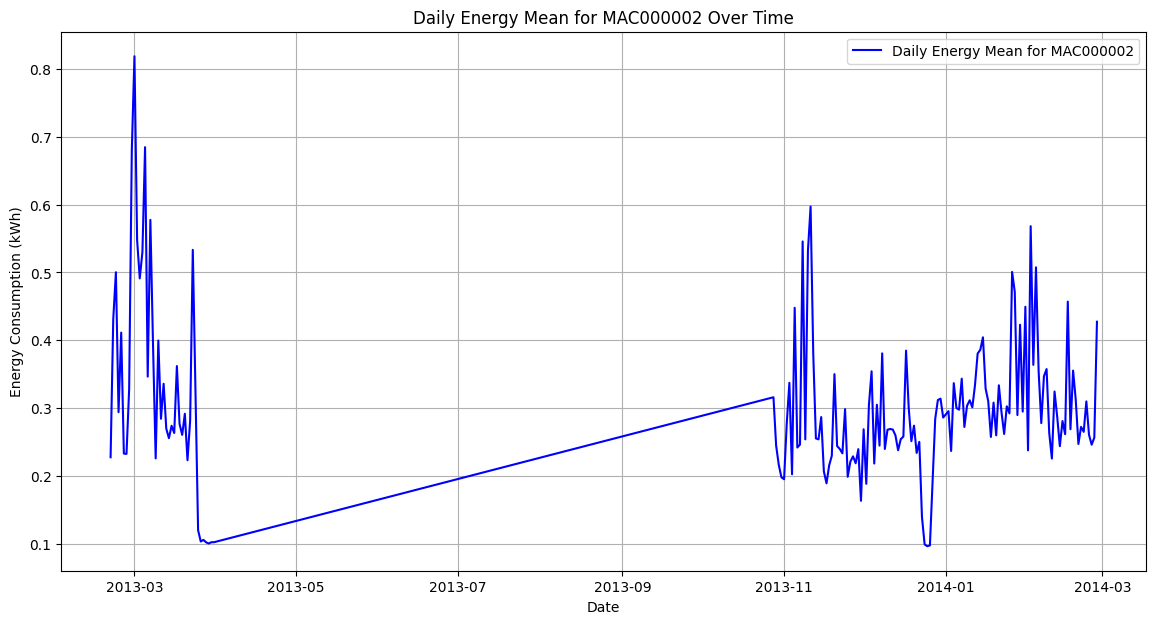

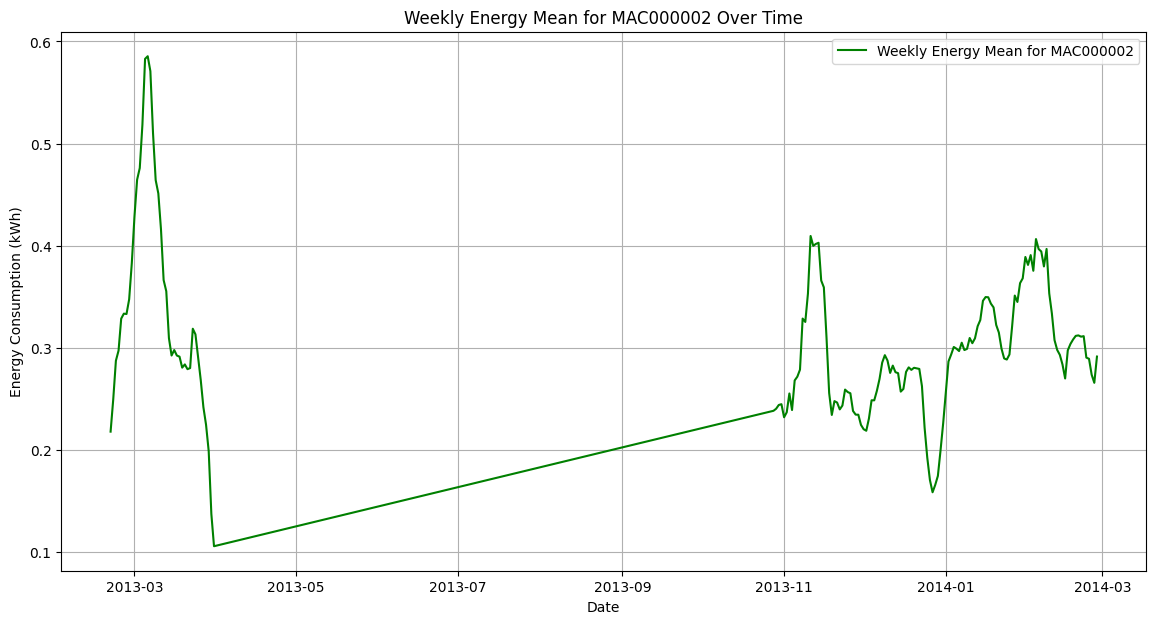

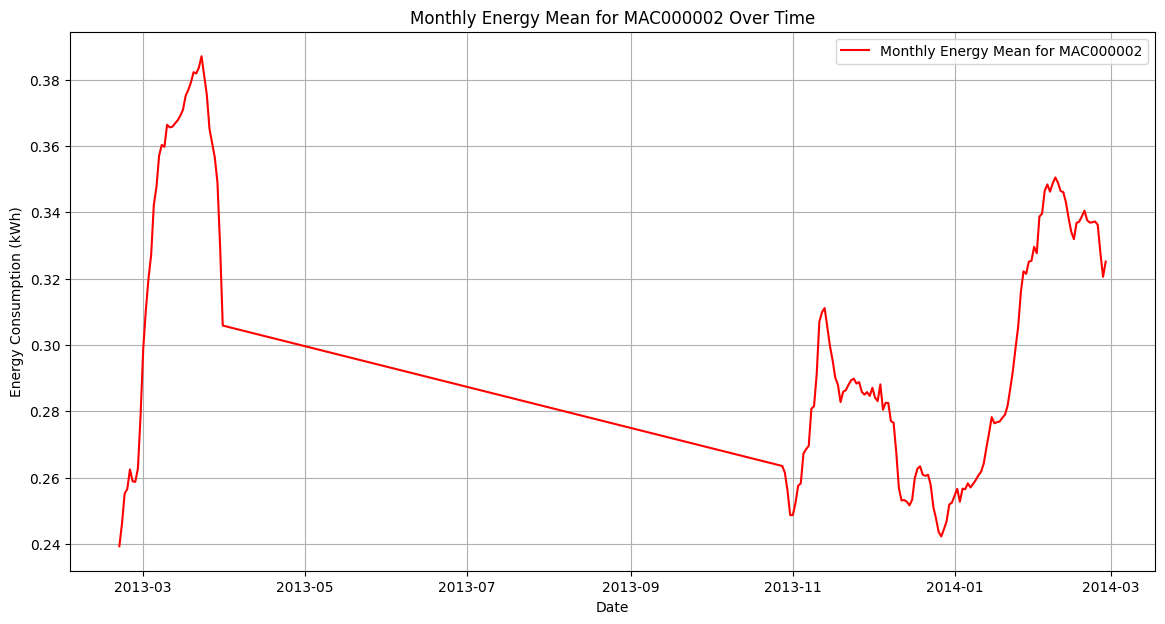

In [12]:
#line plot for actual data

specific_lclid = 'MAC000002'
subset_df = daily_energy_consumption[daily_energy_consumption['LCLid'] == specific_lclid]

#daily
plt.figure(figsize=(14, 7))
plt.plot(subset_df['day'], subset_df['energy_mean'], label=f'Daily Energy Mean for {specific_lclid}', color='blue')
plt.title(f'Daily Energy Mean for {specific_lclid} Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

#weekly
plt.figure(figsize=(14, 7))
plt.plot(subset_df['day'], subset_df['weekly_energy_mean'], label=f'Weekly Energy Mean for {specific_lclid}', color='green')
plt.title(f'Weekly Energy Mean for {specific_lclid} Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

#monthly
plt.figure(figsize=(14, 7))
plt.plot(subset_df['day'], subset_df['monthly_energy_mean'], label=f'Monthly Energy Mean for {specific_lclid}', color='red')
plt.title(f'Monthly Energy Mean for {specific_lclid} Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()


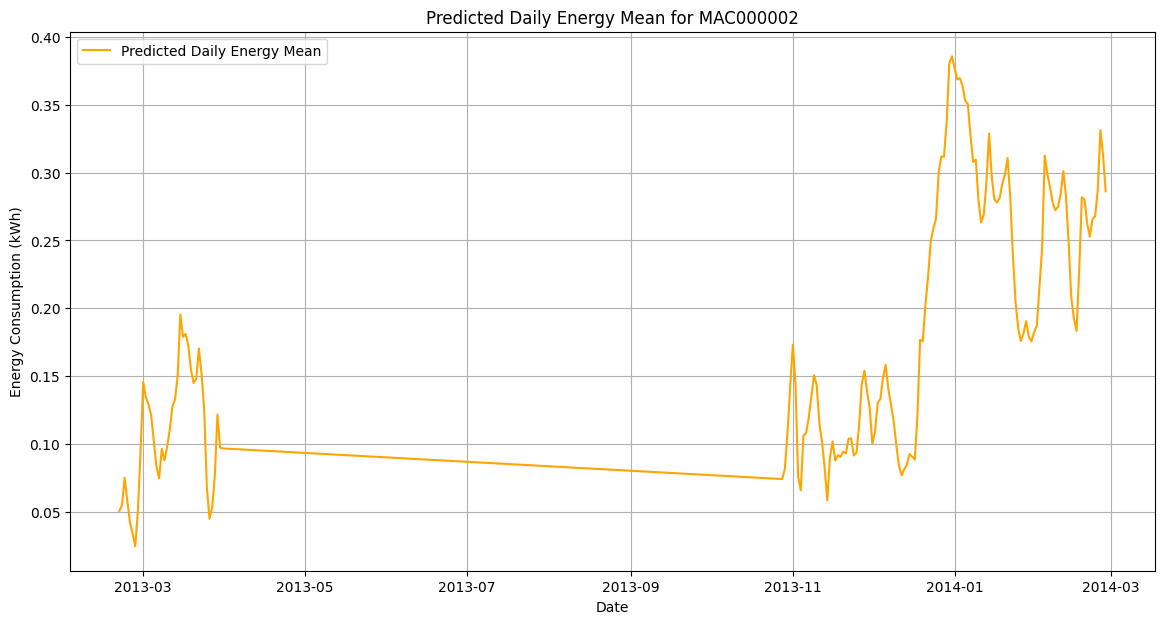

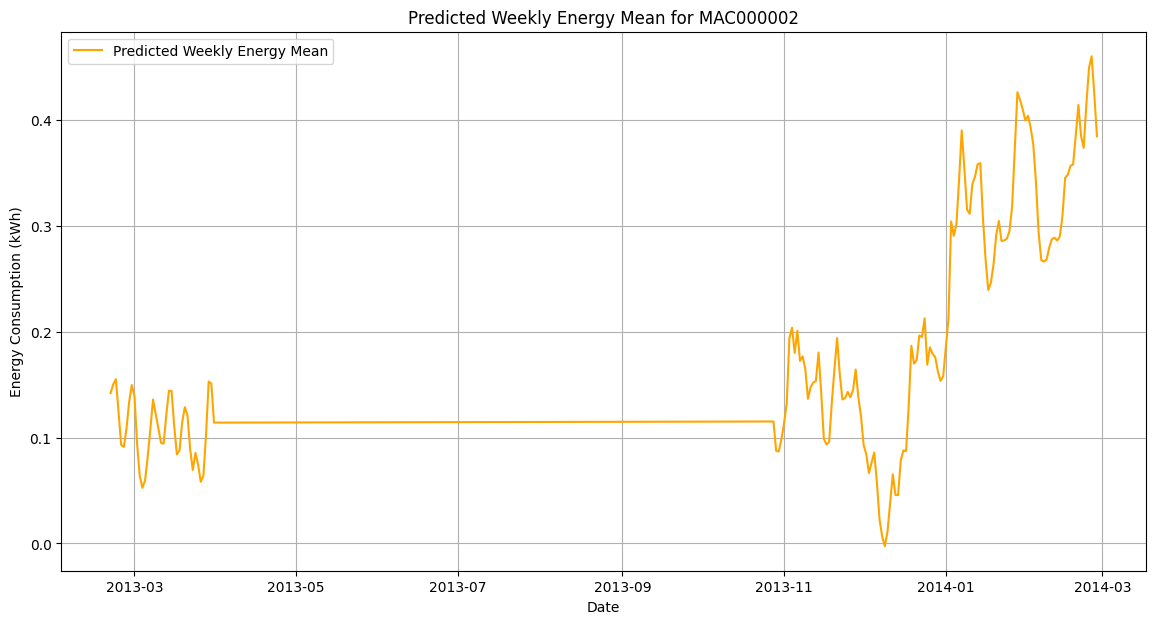

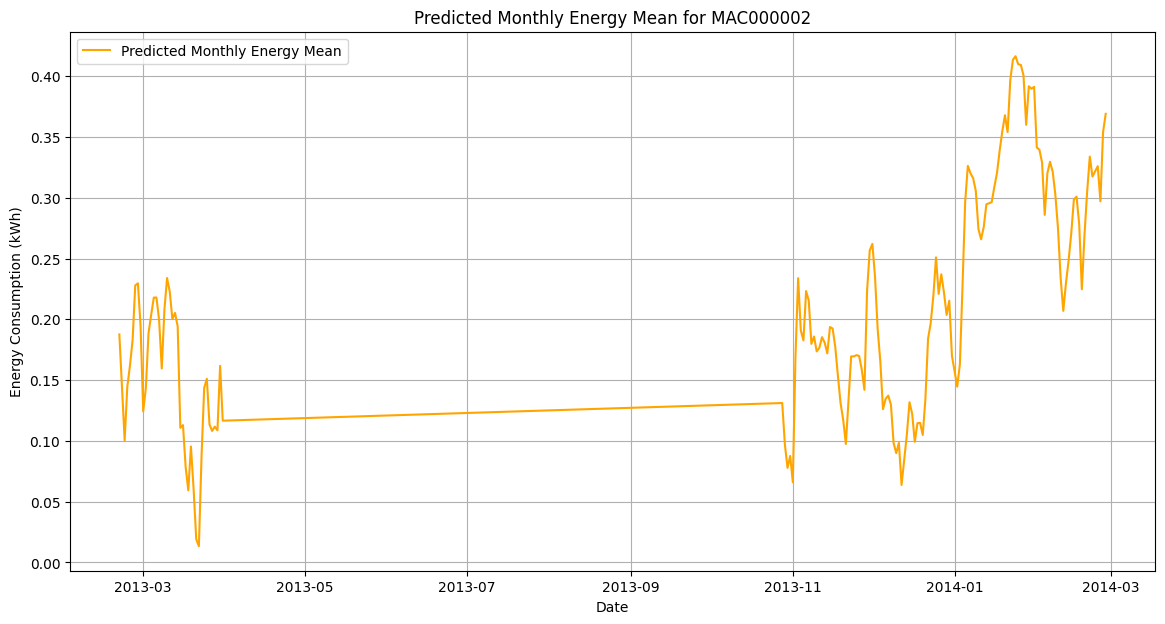

In [17]:
#line plot for predictions
import matplotlib.pyplot as plt

specific_lclid = 'MAC000002'
subset_actual = daily_energy_consumption[daily_energy_consumption['LCLid'] == specific_lclid]

#daily
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_pred_daily_inv[:len(subset_actual)], label='Predicted Daily Energy Mean', color='orange')
plt.title(f'Predicted Daily Energy Mean for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

#weekly
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_pred_weekly_inv[:len(subset_actual)], label='Predicted Weekly Energy Mean', color='orange')
plt.title(f'Predicted Weekly Energy Mean for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

#monthly
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_pred_monthly_inv[:len(subset_actual)], label='Predicted Monthly Energy Mean', color='orange')
plt.title(f'Predicted Monthly Energy Mean for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()



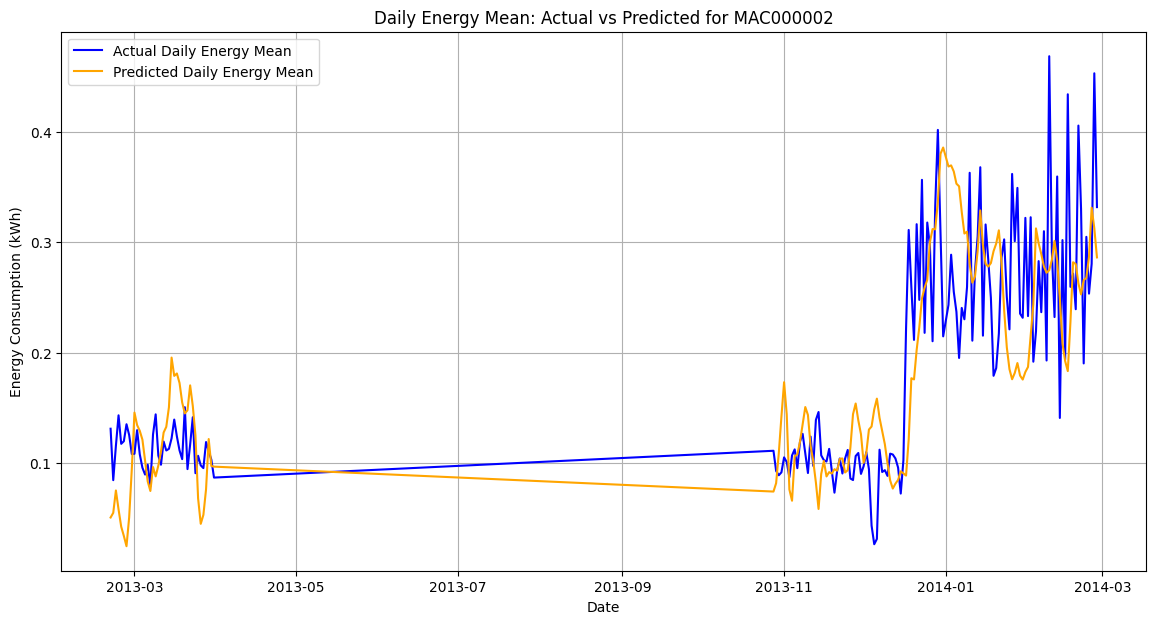

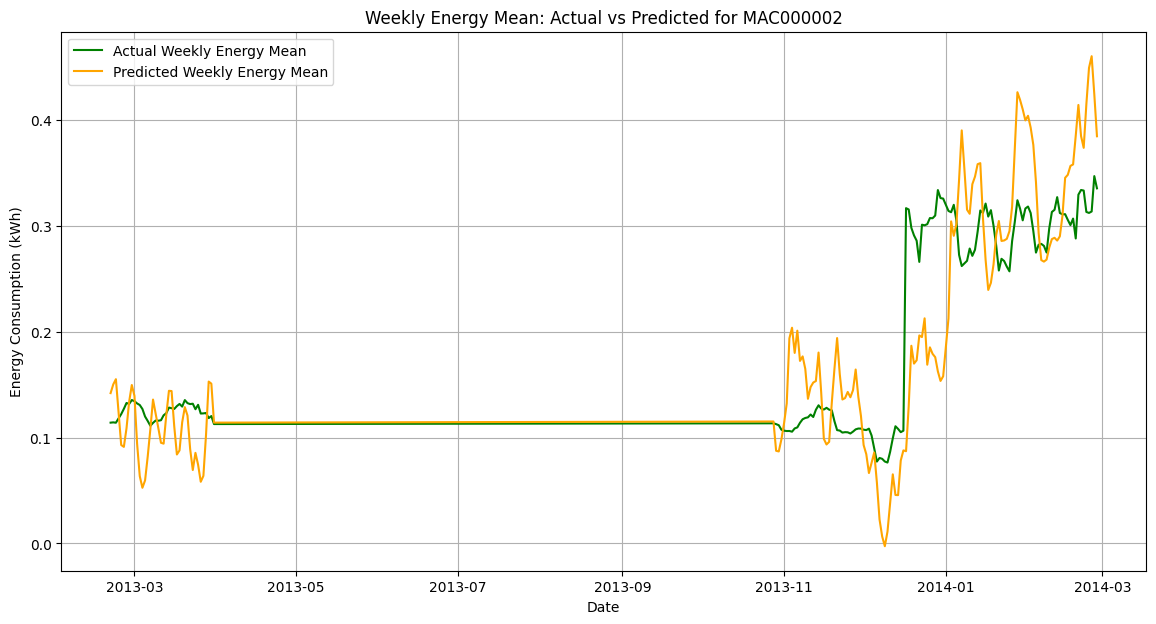

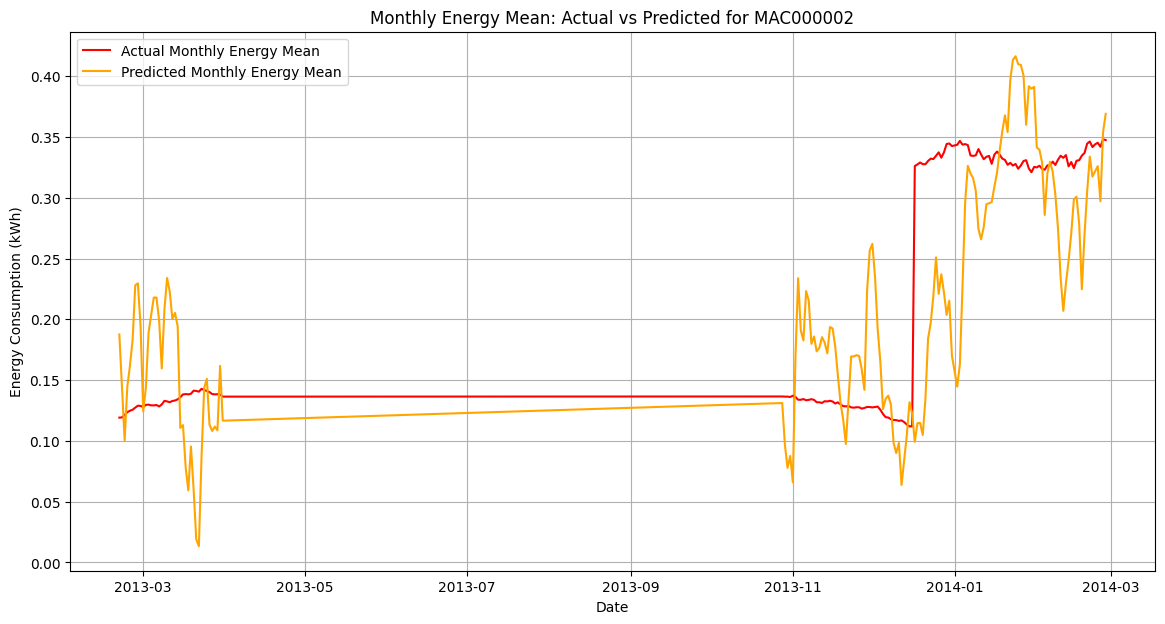

In [16]:
# actual vs predicted values
import matplotlib.pyplot as plt

specific_lclid = 'MAC000002'
subset_actual = daily_energy_consumption[daily_energy_consumption['LCLid'] == specific_lclid]

# Plotting Daily:Actual vs Predicted
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_test_daily_inv[:len(subset_actual)], label='Actual Daily Energy Mean', color='blue')
plt.plot(subset_actual['day'], y_pred_daily_inv[:len(subset_actual)], label='Predicted Daily Energy Mean', color='orange')
plt.title(f'Daily Energy Mean: Actual vs Predicted for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Weekly: Actual vs Predicted
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_test_weekly_inv[:len(subset_actual)], label='Actual Weekly Energy Mean', color='green')
plt.plot(subset_actual['day'], y_pred_weekly_inv[:len(subset_actual)], label='Predicted Weekly Energy Mean', color='orange')
plt.title(f'Weekly Energy Mean: Actual vs Predicted for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Monthly: Actual vs Predicted
plt.figure(figsize=(14, 7))
plt.plot(subset_actual['day'], y_test_monthly_inv[:len(subset_actual)], label='Actual Monthly Energy Mean', color='red')
plt.plot(subset_actual['day'], y_pred_monthly_inv[:len(subset_actual)], label='Predicted Monthly Energy Mean', color='orange')
plt.title(f'Monthly Energy Mean: Actual vs Predicted for {specific_lclid}')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()


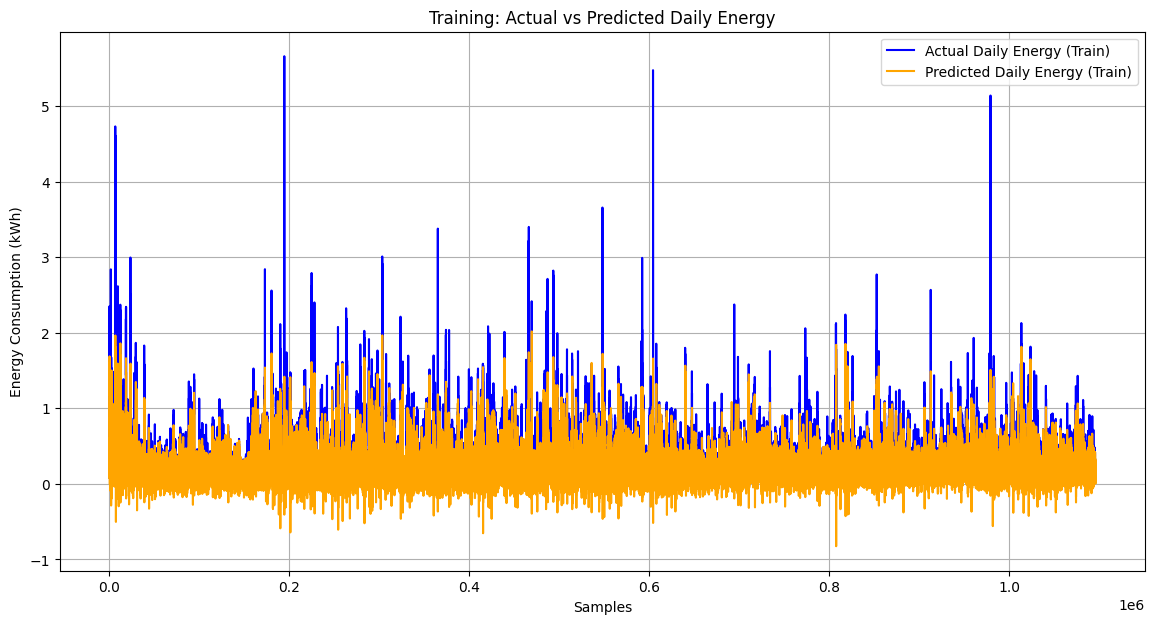

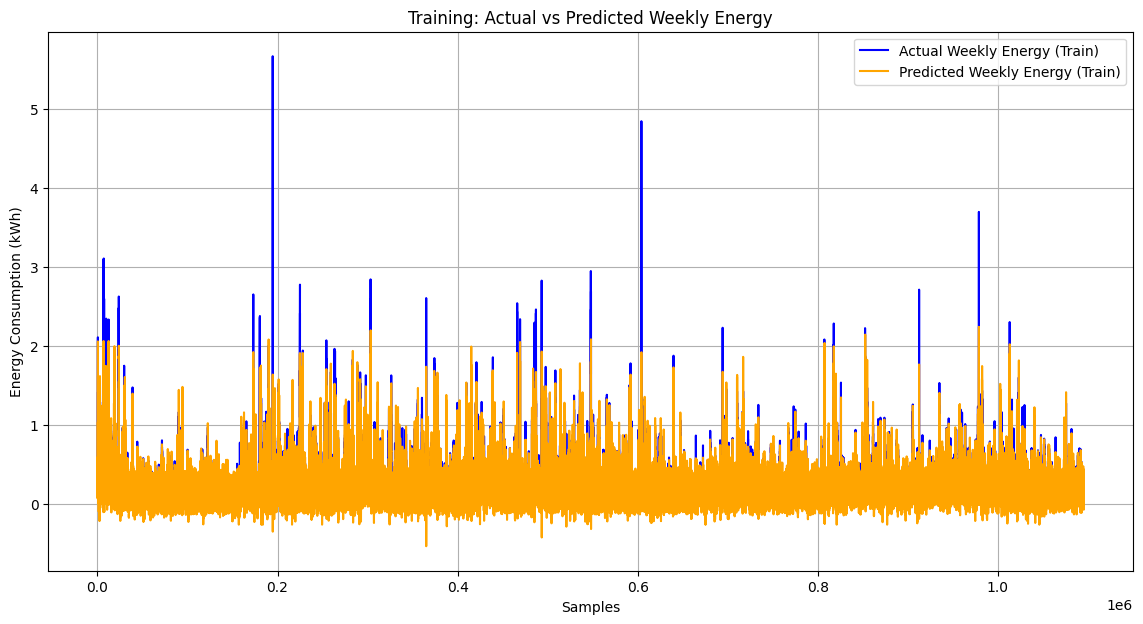

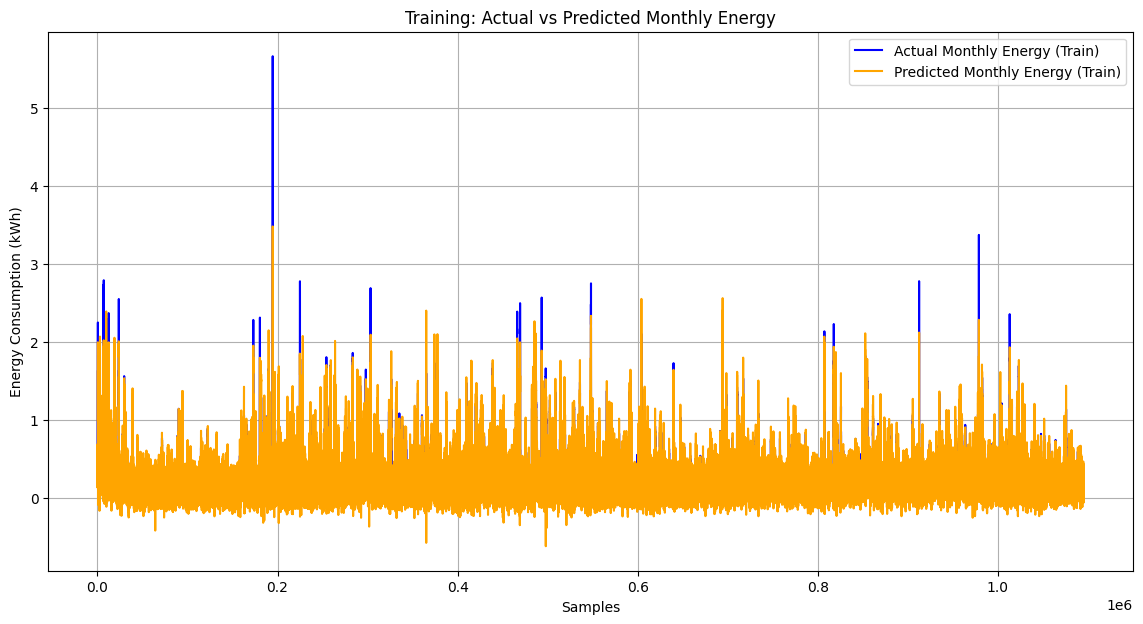

In [20]:
#Plotting Predictions for Training and Testing Sets

##Plotting daily predictions
plt.figure(figsize=(14, 7))
plt.plot(y_train_daily_inv, label='Actual Daily Energy (Train)', color='blue')
plt.plot(y_train_pred_daily_inv, label='Predicted Daily Energy (Train)', color='orange')
plt.title('Training: Actual vs Predicted Daily Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Weekly Predictions
plt.figure(figsize=(14, 7))
plt.plot(y_train_weekly_inv, label='Actual Weekly Energy (Train)', color='blue')
plt.plot(y_train_pred_weekly_inv, label='Predicted Weekly Energy (Train)', color='orange')
plt.title('Training: Actual vs Predicted Weekly Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting  Monthly Predictions
plt.figure(figsize=(14, 7))
plt.plot(y_train_monthly_inv, label='Actual Monthly Energy (Train)', color='blue')
plt.plot(y_train_pred_monthly_inv, label='Predicted Monthly Energy (Train)', color='orange')
plt.title('Training: Actual vs Predicted Monthly Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()


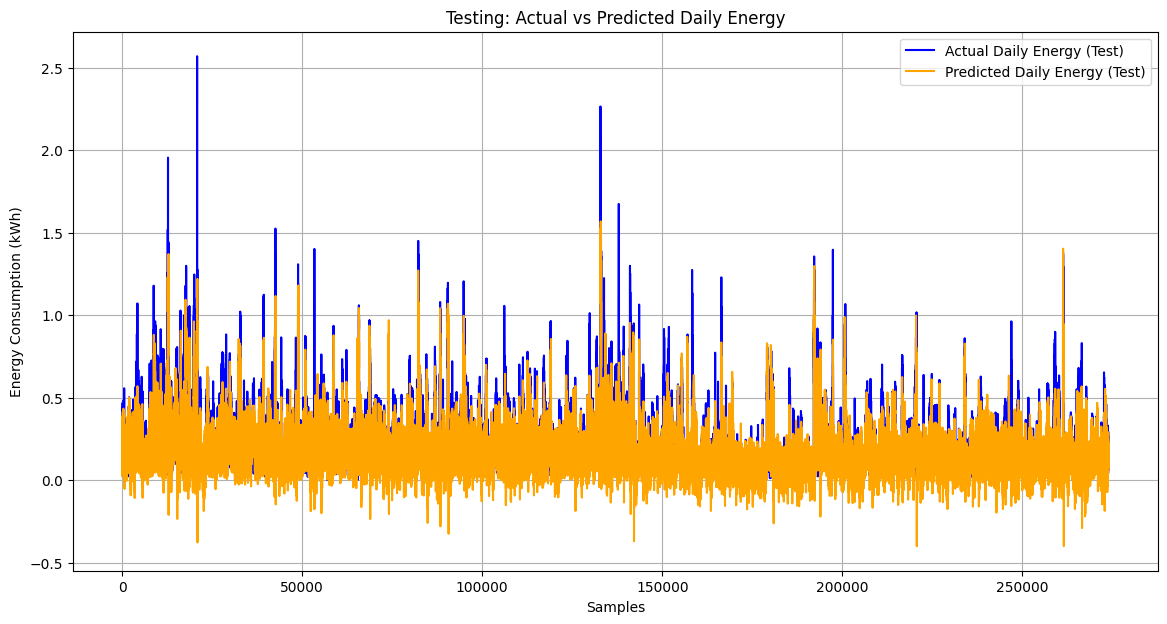

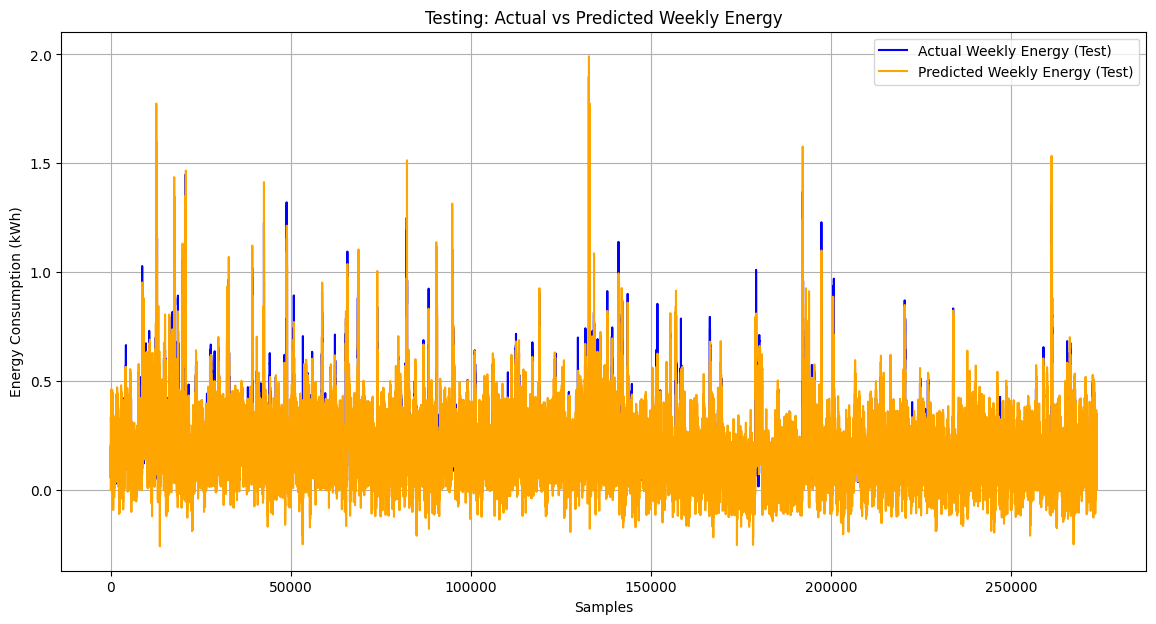

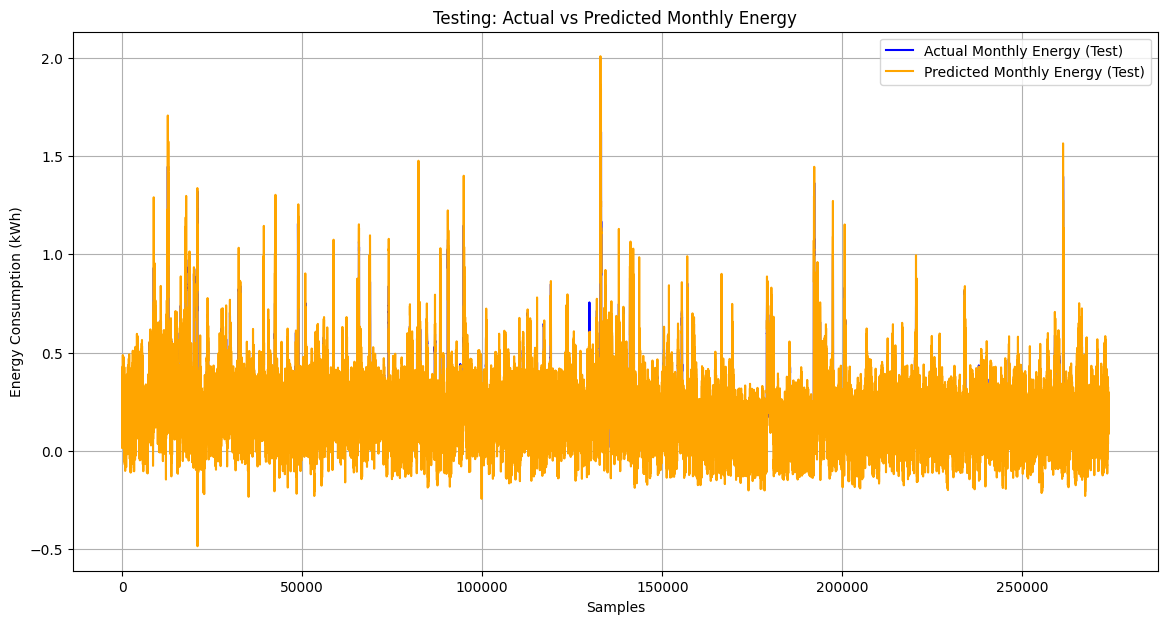

In [21]:
##Plotting Testing Predictions

# Plotting  Daily Predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test_daily_inv, label='Actual Daily Energy (Test)', color='blue')
plt.plot(y_test_pred_daily_inv, label='Predicted Daily Energy (Test)', color='orange')
plt.title('Testing: Actual vs Predicted Daily Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting weekly Predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test_weekly_inv, label='Actual Weekly Energy (Test)', color='blue')
plt.plot(y_test_pred_weekly_inv, label='Predicted Weekly Energy (Test)', color='orange')
plt.title('Testing: Actual vs Predicted Weekly Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Monthly Predictions
plt.figure(figsize=(14, 7))
plt.plot(y_test_monthly_inv, label='Actual Monthly Energy (Test)', color='blue')
plt.plot(y_test_pred_monthly_inv, label='Predicted Monthly Energy (Test)', color='orange')
plt.title('Testing: Actual vs Predicted Monthly Energy')
plt.xlabel('Samples')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()
